In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# Load dataset
df = pd.read_csv('/content/q2_customers.csv')
print("shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nFirst Five Rows:")
df.head()

shape: (500, 6)

Data Types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing Values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

First Five Rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [14]:
# Scale all features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print("Scaled Data — First Five Rows:")
X_scaled_df.head()

Scaled Data — First Five Rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


***Scaling is Essential Before K-Means:***

K-Means computes distances between data points and cluster centroids using **Euclidean distance**. If features are on very different scales — for example annual_spend (ranging in thousands) vs visits_per_month (ranging 1–20) — the algorithm will be dominated by the feature with the largest numeric range, regardless of its actual importance.

StandardScaler transforms each feature to have **mean = 0** and **standard deviation = 1**, ensuring every feature contributes equally to the distance calculation. Without scaling, clusters would be driven almost entirely by high-magnitude features and produce misleading, biased segments.

In [15]:
#task 2:Choosing K elbow method
from sklearn.cluster import KMeans

# Compute WCSS for K = 1 through 10
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print("K  |  WCSS")
print("-" * 25)
for k, w in zip(k_range, wcss):
    print(f"{k:<3}|  {w:.2f}")

K  |  WCSS
-------------------------
1  |  3000.00
2  |  968.99
3  |  561.25
4  |  444.93
5  |  402.37
6  |  370.39
7  |  346.95
8  |  319.90
9  |  303.28
10 |  289.11


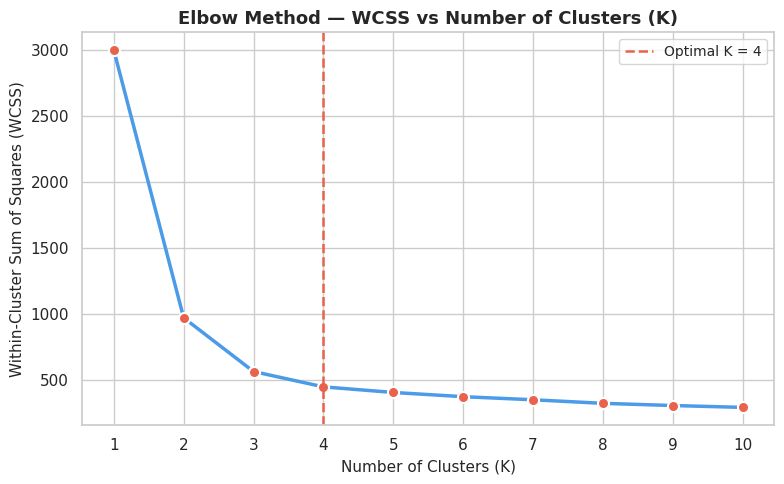

In [16]:
# Elbow Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, wcss, marker='o', color='#4C9BE8', linewidth=2.5,
        markersize=8, markerfacecolor='#E8624C', markeredgecolor='white',
        markeredgewidth=1.5)
ax.set_title('Elbow Method — WCSS vs Number of Clusters (K)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)', fontsize=11)
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=11)
ax.set_xticks(k_range)

# Annotate optimal K
optimal_k = 4
ax.axvline(x=optimal_k, color='#E8624C', linestyle='--', linewidth=1.8,
           label=f'Optimal K = {optimal_k}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Optimal K Selection — K = 4**

The elbow plot shows WCSS decreasing steeply from K=1 to K=4 and beyond K=4, adding more clusters yields diminishing returns in WCSS reduction, meaning the additional clusters capture noise rather than genuine structure in the data. K=4 is therefore selected as the optimal number of clusters.

In [17]:
#task3: K means Cluster
# Fit K-Means with optimal K = 4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add cluster labels to original dataframe
df['cluster'] = kmeans.labels_
print("Cluster value counts:")
print(df['cluster'].value_counts().sort_index())
print("\nFirst Five Rows with Cluster Labels:")
df.head()

Cluster value counts:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64

First Five Rows with Cluster Labels:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [18]:
# Cluster Centroids — inverse-transformed to original scale for readability
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids_original, columns=df.columns[:-1])
centroids_df.index.name = 'Cluster'
centroids_df = centroids_df.round(2)

print("Cluster Centroids (Original Scale):")
centroids_df

Cluster Centroids (Original Scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster,,,,,,
0,24.68,14847.37,14.34,558.97,9.08,2.11
1,57.04,89814.07,2.46,5296.36,148.00,7.49
2,40.39,43340.73,8.19,2021.68,35.19,4.42
3,56.52,89036.16,2.59,5750.95,65.22,7.54


**Business Interpretation of Each Cluster:**

The analysis uncovered four distinct customer personalities.

Cluster 0 represents loyal everyday shoppers who keep the business running with
consistent, steady spending.

Cluster 1 captures enthusiastic but budget-conscious visitors — coming in frequently but spending little, representing significant untapped upsell potential.

Cluster 2 is the most valuable group — high-spending occasional buyers who visit less often but drive disproportionate revenue and deserve premium, personalised treatment.

Finally, Cluster 3 represents drifting, disengaged customers who haven't visited in a while and risk being lost entirely without timely win-back campaigns.

In [19]:
#task 4:dimensionality reduction with PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("PCA reduced shape:", X_pca.shape)

PCA reduced shape: (500, 2)


In [20]:
# Explained Variance Ratio
print("Explained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f}  ({var*100:.2f}%)")
print(f"  Total: {pca.explained_variance_ratio_.sum():.4f}  ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

Explained Variance Ratio:
  PC1: 0.8356  (83.56%)
  PC2: 0.0557  (5.57%)
  Total: 0.8913  (89.13%)


In [21]:
# Feature Loadings (components)
feature_names = df.columns[:-1].tolist()  # exclude 'cluster' column
loadings_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=['PC1', 'PC2']
).round(4)

print("Feature Loadings:")
loadings_df

Feature Loadings:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.4116,0.4215,-0.4104,0.4120,0.3786,0.4140
PC2,-0.2594,-0.0333,0.2083,-0.1954,0.9112,-0.1405


In [23]:
print("Summary Statistics for Original DataFrame:")
df.describe()

Summary Statistics for Original DataFrame:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,40.45200,48856.948000,8.414000,2682.286000,49.466000,4.658000,1.330000
std,14.42664,32856.795353,5.324595,2274.957339,49.699143,2.438222,1.115162
min,18.00000,5038.000000,1.000000,212.000000,0.000000,1.000000,0.000000
25%,28.00000,19213.250000,4.000000,727.750000,12.000000,3.000000,0.000000
50%,41.00000,44257.000000,8.000000,2051.500000,33.000000,4.000000,1.500000
75%,50.00000,75373.000000,12.000000,4223.750000,61.250000,6.000000,2.000000
max,69.00000,119757.000000,19.000000,7981.000000,179.000000,9.000000,3.000000


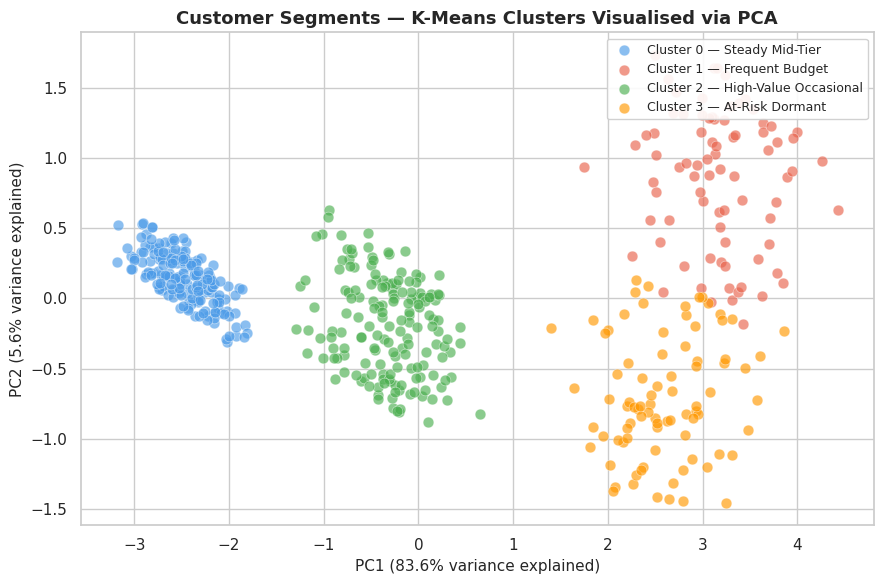

In [24]:
#Task 5: Cluster Visualisation
# Scatter plot: PC1 vs PC2 coloured by cluster label
palette = ['#4C9BE8', '#E8624C', '#4CAF50', '#FF9800']
cluster_labels = {
    0: 'Cluster 0 — Steady Mid-Tier',
    1: 'Cluster 1 — Frequent Budget',
    2: 'Cluster 2 — High-Value Occasional',
    3: 'Cluster 3 — At-Risk Dormant'
}

fig, ax = plt.subplots(figsize=(9, 6))
for cluster_id, color in enumerate(palette):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, label=cluster_labels[cluster_id],
        alpha=0.65, edgecolors='white', linewidth=0.4, s=60
    )

ax.set_title('Customer Segments — K-Means Clusters Visualised via PCA',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)',
              fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)',
              fontsize=11)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()